# Filtering of Deterministic Continuous-Time Processes

In this notebook, we show how we can perform inference in deterministic continuous-time processes, using the Lorenz 63 ODE as an example. We present three different methods: (i) `LatentPathBuilder`, (ii) the EnKF on the discretized flow of the ODE, and (iii) the EKF on a dicretized and jittered version of the flow.

## Discretization Pattern

In general, we can use a `Discretizer` handler with an `ODEFlowConfig` to discretize an ODE into a discrete-time state evolution. With `jitter_scale = 0.0`, the resulting state transition is a `Delta` distribution; with `jitter_scale > 0`, it becomes an independent normal. These can be composed with any other way to do discrete-time inference:

```python
flow = ODEFlowConfig(simulator_config=ode_config)
with Filter(EnKFConfig(filter_source="cuthbert", inflation_delta=0.08)):
    with Discretizer(flow):
        model(obs_times=obs_times, obs_values=obs_values, rho=TRUE_RHO)

jittered_flow = ODEFlowConfig(
    simulator_config=ode_config,
    jitter_scale=1e-2,
)
with Filter(EKFConfig(filter_source="cuthbert")):
    with Discretizer(jittered_flow):
        model(obs_times=obs_times, obs_values=obs_values, rho=TRUE_RHO)
```

## Model and experimental design

We use the deterministic Lorenz–63 system

$$
\frac{dX_t}{dt}=f(X_t;\rho),\qquad
f(x;\rho)=
\begin{pmatrix}
10(x_2-x_1)\\
x_1(
ho-x_3)-x_2\\
x_1x_2-\frac{8}{3}x_3
\end{pmatrix},\qquad \rho_\star=28.
$$

Following the data design in [Part 12: Observation scoring for filter predictive distributions](../tutorials/gentle_intro/12_observation_scoring_with_filters.ipynb), the initial condition has a broad Gaussian distribution, only the first coordinate is observed with unit-variance Gaussian noise, and we discard a long burn-in before analysis. The only substantive change is that the process diffusion is removed: the latent trajectory is generated by an ODE rather than an SDE.

$$
X_0\sim\mathcal N(0,20^2I_3),\qquad
Y_k=[1\;0\;0]X_{t_k}+\varepsilon_k,\qquad
\varepsilon_k\sim\mathcal N(0,1).
$$

Data are generated every $0.05$ time units, with a burn-in of 100 and a retained duration of 15. To keep the results relatively fast, we retain $t \leq 8$ for inference.

In [1]:
import os
import time
from pathlib import Path

import diffrax as dfx
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from IPython.display import Markdown, display
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    LinearGaussianObservation,
    ODESimulator,
    ODESimulatorConfig,
)
from dynestyx.discretizers import Discretizer, ODEFlowConfig
from dynestyx.inference.configs.filter import EKFConfig, EnKFConfig
from dynestyx.inference.configs.smoother import EnRTSSmootherConfig
from dynestyx.inference.filters import Filter
from dynestyx.inference.smoothers import Smoother

STATE_DIM = 3
TRUE_RHO = 28.0
OBS_DT = 0.05
OBS_BURN_IN_TIME = 100.0
OBS_FINAL_TIME = 15.0
ANALYSIS_FINAL_TIME = 8.0
N_ENSEMBLE = 30
N_WARMUP = 100
N_SAMPLES = 100
ENKF_INFLATION_DELTA = 0.08
EKF_JITTER_SCALE = 1e-2
FULL_SIM_TIMES = jnp.arange(
    0.0, OBS_BURN_IN_TIME + OBS_FINAL_TIME + 1e-9, OBS_DT
)

METHOD_COLORS = {
    "LatentPathBuilder": "#E64B35",
    "EnKF + inflation": "#009E73",
    "EKF + jitter": "#56B4E9",
    "EnRTS + inflation": "#F0E442",
}
TRUTH_COLOR = "#222222"
OBS_COLOR = "#5F5F5F"

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.9,
    "lines.linewidth": 2.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
})

default_figure_dir = (
    Path("docs/deep_dives/figures/filtering_deterministic_processes")
    if Path("docs").exists()
    else Path("figures/filtering_deterministic_processes")
)
FIGURE_DIR = Path(os.environ.get("DYNESTYX_FIGURE_DIR", default_figure_dir))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")


def box_axis(ax):
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.9)
    ax.tick_params(direction="out")


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.pdf")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300)

In [2]:
ode_config = ODESimulatorConfig(
    solver=dfx.Tsit5(),
    stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-8),
    adjoint=dfx.RecursiveCheckpointAdjoint(),
    dt0=1e-2,
    max_steps=100_000,
    throw=False,
)


def l63_partial_observation_model(
    obs_times=None, obs_values=None, predict_times=None, rho=None
):
    rho = numpyro.sample("rho", dist.Uniform(23.0, 33.0), obs=rho)

    def drift(x, u, t):
        return jnp.array([
            10.0 * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - (8.0 / 3.0) * x[2],
        ])

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(STATE_DIM),
            covariance_matrix=20.0**2 * jnp.eye(STATE_DIM),
        ),
        state_evolution=ContinuousTimeStateEvolution(drift=drift),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[1.0]]),
        ),
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


def simulate_dataset(
    *, rho=TRUE_RHO, key=jr.PRNGKey(0), full_times=FULL_SIM_TIMES
):
    predictive = Predictive(
        l63_partial_observation_model,
        num_samples=1,
        exclude_deterministic=False,
    )
    with ODESimulator(simulator_config=ode_config):
        synthetic = predictive(key, rho=rho, predict_times=full_times)

    full_times = synthetic["f_times"][0, 0]
    full_states = synthetic["f_states"][0, 0]
    full_observations = synthetic["f_observations"][0, 0]
    keep = full_times >= OBS_BURN_IN_TIME - 1e-12
    return {
        "times": full_times[keep] - OBS_BURN_IN_TIME,
        "states": full_states[keep],
        "observations": full_observations[keep],
    }

## Generate synthetic data

We simulate one noisy, partially observed trajectory and keep only the post-burn-in segment. The state path is deterministic conditional on its sampled initial state, but the observations remain noisy.

retained observations: 301
observations used in comparison: 161
observation shape per time step: (1,)


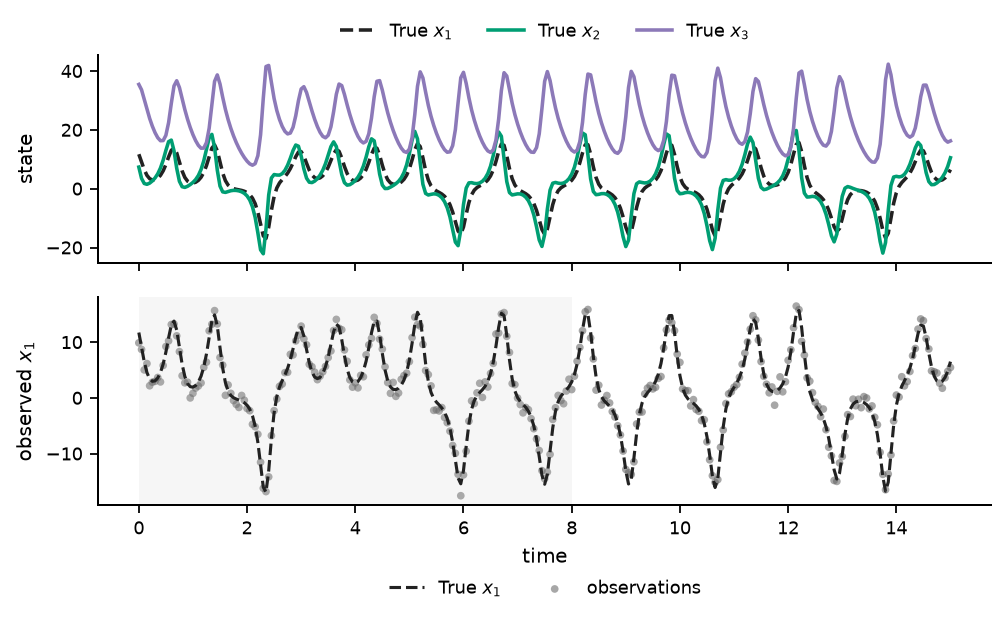

In [3]:
dataset = simulate_dataset()
analysis_mask = dataset["times"] <= ANALYSIS_FINAL_TIME + 1e-12
obs_times = dataset["times"][analysis_mask]
obs_values = dataset["observations"][analysis_mask]
true_states = dataset["states"][analysis_mask]

print(f"retained observations: {dataset['observations'].shape[0]}")
print(f"observations used in comparison: {obs_values.shape[0]}")
print(f"observation shape per time step: {obs_values.shape[1:]}")

fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.4), sharex=True)
state_colors = ["#222222", "#009E73", "#8C79B8"]
state_styles = ["--", "-", "-"]
for index, (color, linestyle) in enumerate(zip(state_colors, state_styles, strict=True)):
    axes[0].plot(
        np.asarray(dataset["times"]),
        np.asarray(dataset["states"][:, index]),
        color=color,
        linestyle=linestyle,
        linewidth=1.6,
        label=fr"True $x_{index + 1}$",
    )
axes[0].set_ylabel("state")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.23), ncol=3)

axes[1].plot(
    np.asarray(dataset["times"]),
    np.asarray(dataset["states"][:, 0]),
    color=TRUTH_COLOR,
    linestyle="--",
    linewidth=1.4,
    label=r"True $x_1$",
)
axes[1].scatter(
    np.asarray(dataset["times"]),
    np.asarray(dataset["observations"][:, 0]),
    s=12,
    color=OBS_COLOR,
    alpha=0.55,
    edgecolors="none",
    label="observations",
)
axes[1].axvspan(
    0.0, ANALYSIS_FINAL_TIME, color="#BDBDBD", alpha=0.12, linewidth=0
)
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"observed $x_1$")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)
for ax in axes:
    despine(ax)
fig.subplots_adjust(hspace=0.16, top=0.88, bottom=0.24)
save_figure(fig, "l63_deterministic_data")
plt.show()

## Four representations of uncertainty

**`LatentPathBuilder`.** In an ODE, after the initial condition is determined, the path is deterministic. `LatentPathBuilder` works by sampling that initial state, then reconstructs the state path and scores this against the observations. We can then sample the initial condition with NUTS, $p(x_0 \,|\, y_{0:T})$, which incudes a posterior over the entire trajectory. This gives a smoothing solution.

**EnKF with flow and inflation.** We can also use the above discretizer pattern with an EnKF, using covariance inflation as a technique to avoid ensemble collapse. For this, we'll use the exact Dirac delta transition, i.e., `ODEFlowConfig(jitter_scale=0)` 

**EKF with jittered flow.** We can also use a "relaxed" version of the ODE flow, where Gaussian noise is added, then use other discrete-time filtering methods. In this example, we'll use the EKF to linearize the flow map, using `jitter_scale=10**-2`. 

**EnRTS with flow and inflation.** Finally, we can solve the smoothing problem --- the same statistical question as `LatentPathBuilder` --- using a smoothing algorithm. In this case, we use the EnRTS smoother.

In [4]:
enkf_config = EnKFConfig(
    n_particles=N_ENSEMBLE,
    crn_seed=jr.PRNGKey(31415),
    inflation_delta=ENKF_INFLATION_DELTA,
    filter_source="cuthbert",
    record_filtered_states_mean=True,
    record_filtered_states_cov_diag=True,
    warn=False,
)
enrts_config = EnRTSSmootherConfig(
    n_particles=N_ENSEMBLE,
    crn_seed=jr.PRNGKey(31415),
    filter_source="cuthbert",
    record_filtered_states_mean=True,
    record_filtered_states_cov_diag=True,
    warn=False,
)
ekf_config = EKFConfig(
    filter_source="cuthbert",
    record_filtered_states_mean=True,
    record_filtered_states_cov_diag=True,
    warn=False,
)
flow_config = ODEFlowConfig(simulator_config=ode_config)
jittered_flow_config = ODEFlowConfig(
    simulator_config=ode_config, jitter_scale=EKF_JITTER_SCALE
)


def run_inference(inference_handler, discretizer_config, key):
    predictive = Predictive(
        l63_partial_observation_model,
        num_samples=1,
        exclude_deterministic=False,
    )
    start = time.perf_counter()
    with inference_handler:
        with Discretizer(discretizer_config):
            samples = predictive(
                key,
                rho=TRUE_RHO,
                obs_times=obs_times,
                obs_values=obs_values,
            )
    elapsed = time.perf_counter() - start

    return samples, elapsed

def run_filter(filter_config, discretizer_config, key):
    samples, elapsed = run_inference(Filter(filter_config=filter_config), discretizer_config, key)
    mean = np.asarray(samples["f_filtered_states_mean"][0])
    variance = np.maximum(
        np.asarray(samples["f_filtered_states_cov_diag"][0]), 0.0
    )
    std = np.sqrt(variance)
    return {
        "mean": mean,
        "lo50": mean - 0.67449 * std,
        "hi50": mean + 0.67449 * std,
        "lo90": mean - 1.64485 * std,
        "hi90": mean + 1.64485 * std,
        "elapsed": elapsed,
    }

def run_smoother(smoother_config, discretizer_config, key):
    samples, elapsed = run_inference(Smoother(smoother_config=smoother_config), discretizer_config, key)
    mean = np.asarray(samples["f_smoothed_states_mean"][0])
    variance = np.maximum(
        np.asarray(samples["f_smoothed_states_cov_diag"][0]), 0.0
    )
    std = np.sqrt(variance)
    return {
        "mean": mean,
        "lo50": mean - 0.67449 * std,
        "hi50": mean + 0.67449 * std,
        "lo90": mean - 1.64485 * std,
        "hi90": mean + 1.64485 * std,
        "elapsed": elapsed,
    }


## Full-path reference with `LatentPathBuilder`

We condition on the known value $\rho=28$, comparing only state estimation performance. NUTS samples initial conditions,then builds and scores a path. We initialize generously: at the first observation for $x_1, x_2$, and a generic value on the attractor for $x_3$.

In [5]:
initial_guess = jnp.array([obs_values[0, 0], obs_values[0, 0], 25.0])
nuts = NUTS(
    l63_partial_observation_model,
    target_accept_prob=0.9,
    init_strategy=init_to_value(
        values={"f_state_path_params": initial_guess}
    ),
    max_tree_depth=7,
)
mcmc = MCMC(
    nuts,
    num_warmup=N_WARMUP,
    num_samples=N_SAMPLES,
    num_chains=1,
)

start = time.perf_counter()
with dsx.LatentPathBuilder(ode_simulator_config=ode_config):
    mcmc.run(
        jr.PRNGKey(2718),
        rho=TRUE_RHO,
        obs_times=obs_times,
        obs_values=obs_values,
    )
latent_elapsed = time.perf_counter() - start
latent_samples = mcmc.get_samples()
latent_paths_raw = np.asarray(latent_samples["f_state_path"])
latent_path_times_raw = np.asarray(latent_samples["f_state_path_times"])
latent_path_times = (
    latent_path_times_raw[0]
    if latent_path_times_raw.ndim > 1
    else latent_path_times_raw
)
obs_indices = np.searchsorted(latent_path_times, np.asarray(obs_times))
latent_paths = latent_paths_raw[:, obs_indices, :]

latent_summary = {
    "mean": np.mean(latent_paths, axis=0),
    "lo50": np.quantile(latent_paths, 0.25, axis=0),
    "hi50": np.quantile(latent_paths, 0.75, axis=0),
    "lo90": np.quantile(latent_paths, 0.05, axis=0),
    "hi90": np.quantile(latent_paths, 0.95, axis=0),
    "elapsed": latent_elapsed,
}
print("posterior path shape:", latent_paths.shape)
print(f"LatentPathBuilder + NUTS: {latent_elapsed:.2f} s")

sample: 100%|██████████| 200/200 [00:29<00:00,  6.89it/s, 47 steps of size 4.96e-04. acc. prob=0.99] 

posterior path shape: (100, 161, 3)
LatentPathBuilder + NUTS: 35.63 s


## Causal filtering through the discrete flow

We can additionally learn via filtering; this solves a different problem, in that state estimates are learned _causally_. We can compare the EnKF, which uses the deterministic transition and uses covariance inflation as a strategy to avoid collapse, and the EKF, which requires a "relaxed" transition via the `jitter_scale` parameter.

In [6]:
enkf_summary = run_filter(enkf_config, flow_config, jr.PRNGKey(11))
ekf_summary = run_filter(ekf_config, jittered_flow_config, jr.PRNGKey(12))

## Smoothing through the discrete flow

We can also use the EnRTS smoother to get a non-causal smoothing distribution, comparable in statistical properties to the `LatentPathBuilder` solution.

In [7]:
enrts_summary = run_smoother(enrts_config, flow_config, jr.PRNGKey(13))

## Comparison Plots

We now run each method and compare performance.

In [8]:
summaries = {
    "LatentPathBuilder": latent_summary,
    "EnKF + inflation": enkf_summary,
    "EKF + jitter": ekf_summary,
    "EnRTS + inflation": enrts_summary,
}

for name, summary in summaries.items():
    print(f"{name:<24} {summary['elapsed']:.2f} s")


LatentPathBuilder        35.63 s
EnKF + inflation         1.51 s
EKF + jitter             3.44 s
EnRTS + inflation        0.88 s


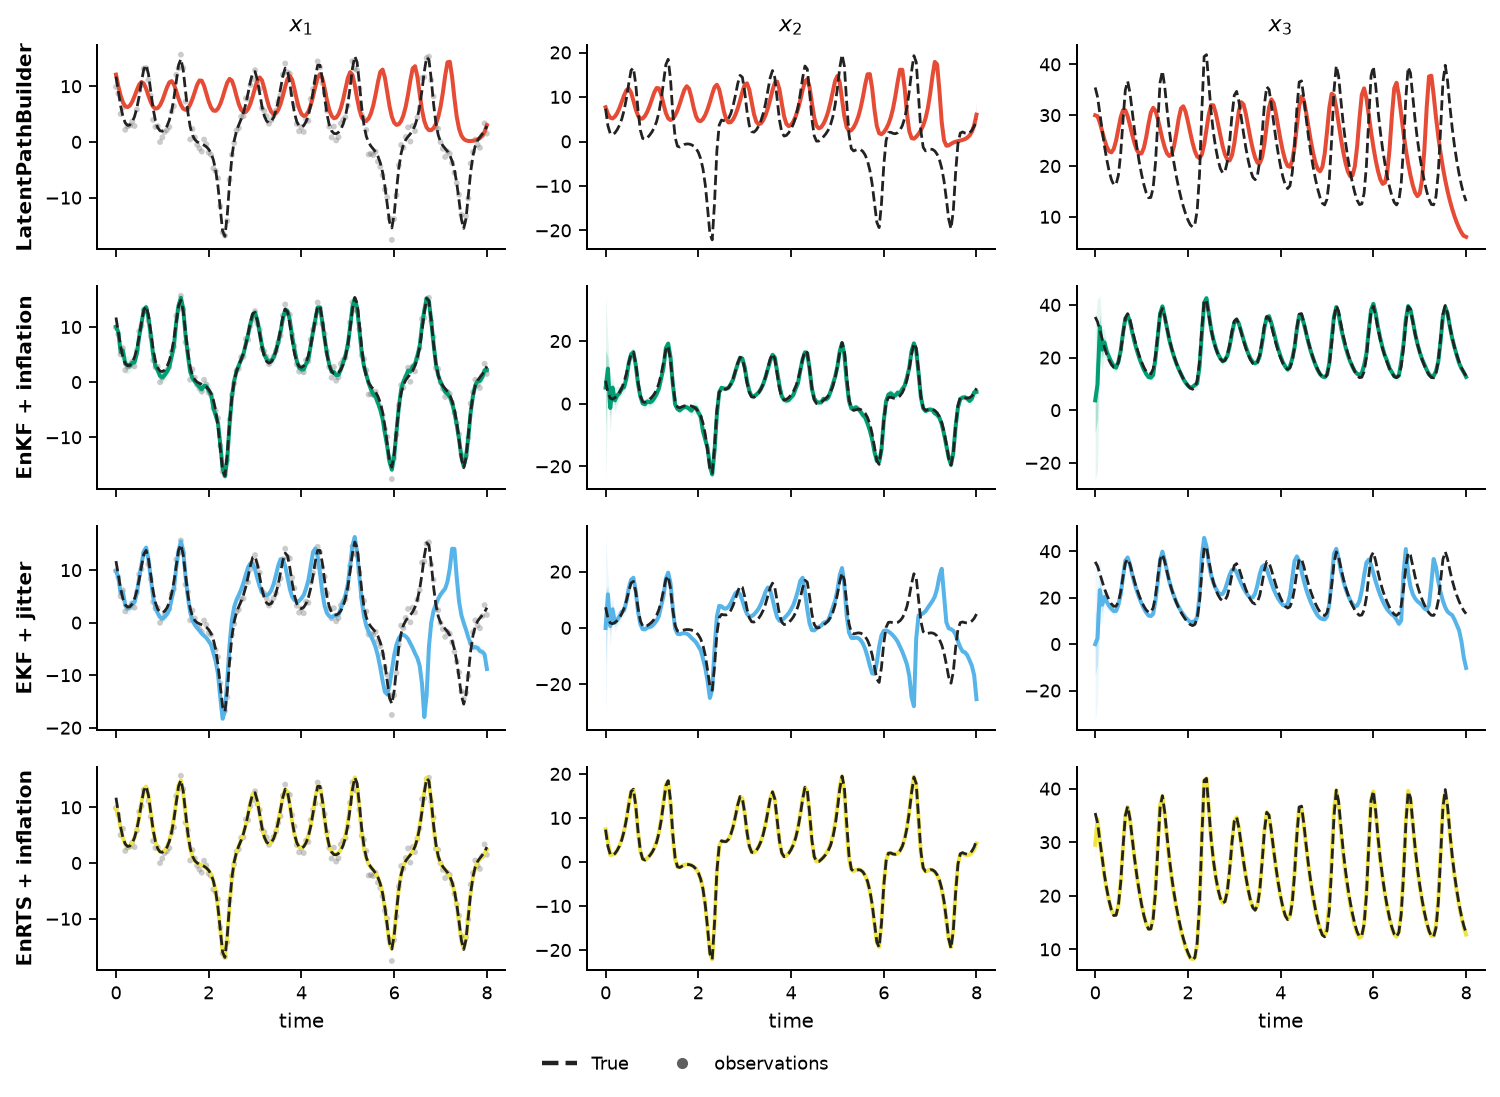

In [9]:
fig, axes = plt.subplots(
    4, 3, figsize=(10.2, 6.8), sharex=True, constrained_layout=False
)
method_names = list(summaries)
times_np = np.asarray(obs_times)
truth_np = np.asarray(true_states)
observations_np = np.asarray(obs_values[:, 0])

for row, method_name in enumerate(method_names):
    summary = summaries[method_name]
    color = METHOD_COLORS[method_name]
    for state_index in range(STATE_DIM):
        ax = axes[row, state_index]
        ax.fill_between(
            times_np,
            summary["lo90"][:, state_index],
            summary["hi90"][:, state_index],
            color=color,
            alpha=0.10,
            linewidth=0,
        )
        ax.fill_between(
            times_np,
            summary["lo50"][:, state_index],
            summary["hi50"][:, state_index],
            color=color,
            alpha=0.24,
            linewidth=0,
        )
        ax.plot(
            times_np,
            summary["mean"][:, state_index],
            color=color,
            linewidth=1.8,
        )
        ax.plot(
            times_np,
            truth_np[:, state_index],
            color=TRUTH_COLOR,
            linestyle="--",
            linewidth=1.25,
        )
        if state_index == 0:
            ax.scatter(
                times_np,
                observations_np,
                s=7,
                color=OBS_COLOR,
                alpha=0.32,
                edgecolors="none",
            )
        if row == 0:
            ax.set_title(fr"$x_{state_index + 1}$", fontweight="bold")
        if state_index == 0:
            ax.set_ylabel(method_name, fontweight="bold")
        if row == len(method_names) - 1:
            ax.set_xlabel("time")
        despine(ax)

legend_handles = [
    mpl.lines.Line2D([], [], color=TRUTH_COLOR, linestyle="--", label="True"),
    mpl.lines.Line2D([], [], color=OBS_COLOR, marker="o", linestyle="none", markersize=4, label="observations"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
)
fig.subplots_adjust(left=0.14, right=0.99, top=0.95, bottom=0.10, hspace=0.18, wspace=0.20)
save_figure(fig, "state_estimates")
plt.show()

We can also state metrics regarding performance; in this case, RMSE and covarage of posteriors at 90\% nomimal credible interval.

| Method | Overall RMSE | 90% coverage | Runtime [s] |
|---|---:|---:|---:|
| LatentPathBuilder | 9.626 | 0.035 | 35.63 |
| EnKF + inflation | 1.985 | 0.934 | 1.51 |
| EKF + jitter | 7.935 | 0.217 | 3.44 |
| EnRTS + inflation | 0.394 | 0.867 | 0.88 |

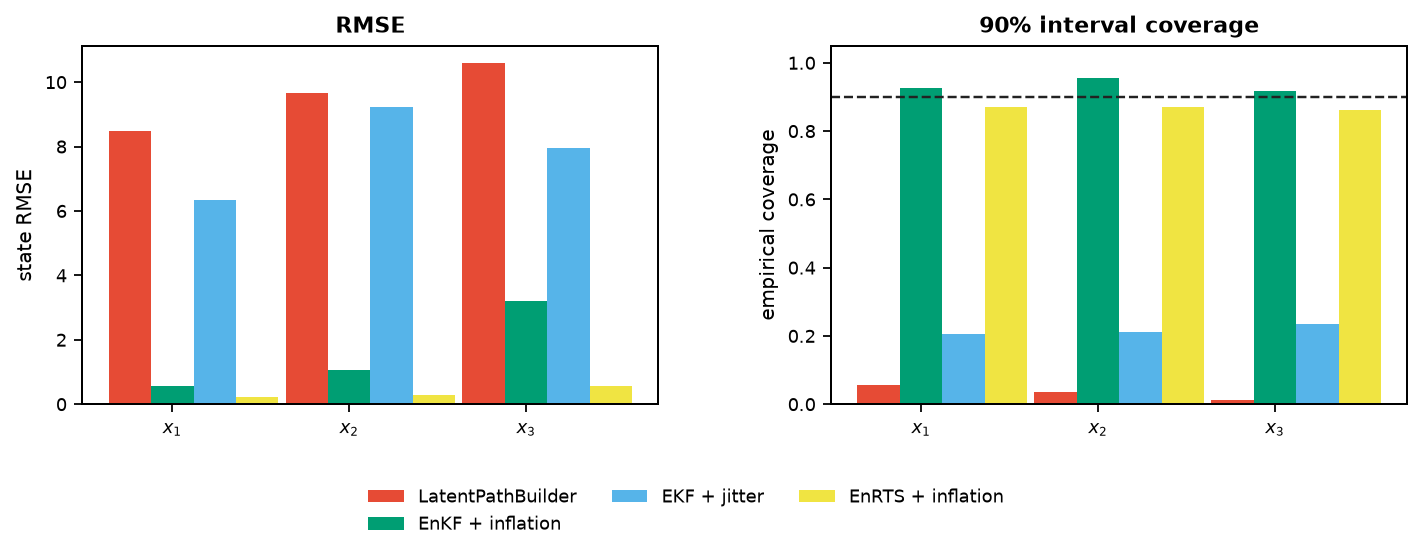

In [10]:
metrics = {}
for name, summary in summaries.items():
    error = summary["mean"] - truth_np
    rmse_by_state = np.sqrt(np.mean(error**2, axis=0))
    covered = (truth_np >= summary["lo90"]) & (truth_np <= summary["hi90"])
    coverage_by_state = np.mean(covered, axis=0)
    metrics[name] = {
        "rmse_by_state": rmse_by_state,
        "coverage_by_state": coverage_by_state,
        "rmse": float(np.sqrt(np.mean(error**2))),
        "coverage": float(np.mean(covered)),
    }

table_lines = [
    "| Method | Overall RMSE | 90% coverage | Runtime [s] |",
    "|---|---:|---:|---:|",
]
for name in method_names:
    table_lines.append(
        f"| {name} | {metrics[name]['rmse']:.3f} | "
        f"{metrics[name]['coverage']:.3f} | {summaries[name]['elapsed']:.2f} |"
    )
display(Markdown("\n".join(table_lines)))

positions = np.arange(STATE_DIM)
bar_width = 0.24
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5))
for method_index, name in enumerate(method_names):
    offset = (method_index - 1) * bar_width
    axes[0].bar(
        positions + offset,
        metrics[name]["rmse_by_state"],
        width=bar_width,
        color=METHOD_COLORS[name],
        label=name,
    )
    axes[1].bar(
        positions + offset,
        metrics[name]["coverage_by_state"],
        width=bar_width,
        color=METHOD_COLORS[name],
    )

axes[0].set_title("RMSE", fontweight="bold")
axes[0].set_ylabel("state RMSE")
axes[0].set_ylim(bottom=0.0)
axes[1].set_title("90% interval coverage", fontweight="bold")
axes[1].set_ylabel("empirical coverage")
axes[1].set_ylim(0.0, 1.05)
axes[1].axhline(0.9, color=TRUTH_COLOR, linestyle="--", linewidth=1.1)
for ax in axes:
    ax.set_xticks(positions, [r"$x_1$", r"$x_2$", r"$x_3$"])
    box_axis(ax)
fig.legend(
    loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3
)
fig.subplots_adjust(left=0.09, right=0.99, top=0.88, bottom=0.24, wspace=0.30)
save_figure(fig, "state_recovery_metrics")
plt.show()

Between these, we see that `LatentPathBuilder` **failed to solve the inverse problem** of learning the initial condition. Meanwhile, EKF learns but is rather miscalibrated and with high error. EnKF learns effectively under the causal filtering problem, and EnRTS learns effectively for the smoothing problem, achieving the lowest overall RMSE.

## Parameter inference

In the above, we assume a known $\rho = 28$ and simulate; we may also use each of the above inference methods for parameter estimation as well. We use a prior $\rho \sim \mathcal{U}(23, 33)$ and attempt to learn both the state path and the parameter $\rho$.

Due to the step size controller we use (PID controller), we are unable to use the EKF for parameter estimation. On the other hand, the marginal likelihood estimate from EnRTS does not differ from EnKF for now, in our dynestyx/cuthbert's current implementations. We thus compare principally `LatentPathBuilder`, which learns $(\rho, x_{0:T})$ jointly, and the EnKF filter, which learns states via the filtering distribution and uses the corresponding marginal likelihood to learn $p(\rho \,|\, y_{0:T})$. In other case, we use NUTS for inference.

In [11]:
from numpyro.infer.initialization import init_to_sample

PARAMETER_N_WARMUP = 100
PARAMETER_N_SAMPLES = 100
NUM_CHAINS = 4

parameter_enkf_config = EnKFConfig(
    n_particles=N_ENSEMBLE,
    crn_seed=jr.PRNGKey(31415),
    inflation_delta=ENKF_INFLATION_DELTA,
    filter_source="cuthbert",
    warn=False,
)


def run_parameter_inference(
    *, name, inference_handler, discretizer_config, key
):
    nuts = NUTS(
        l63_partial_observation_model,
        target_accept_prob=0.9,
        init_strategy=init_to_sample,
        max_tree_depth=7,
    )
    mcmc = MCMC(
        nuts,
        num_warmup=PARAMETER_N_WARMUP,
        num_samples=PARAMETER_N_SAMPLES,
        num_chains=NUM_CHAINS,
        chain_method="vectorized",
    )

    start = time.perf_counter()
    with inference_handler:
        if discretizer_config is None:
            mcmc.run(
                key,
                obs_times=obs_times,
                obs_values=obs_values,
            )
        else:
            with Discretizer(discretizer_config):
                mcmc.run(
                    key,
                    obs_times=obs_times,
                    obs_values=obs_values,
                )

    posterior_by_chain = mcmc.get_samples(group_by_chain=True)
    rho_by_chain = posterior_by_chain["rho"]
    rho_by_chain.block_until_ready()
    elapsed = time.perf_counter() - start

    state_path_params_by_chain = posterior_by_chain.get(
        "f_state_path_params"
    )
    if state_path_params_by_chain is not None:
        state_path_params_by_chain.block_until_ready()

    diagnostics = numpyro.diagnostics.summary(
        {"rho": rho_by_chain}, prob=0.9
    )["rho"]
    divergences = int(
        np.asarray(
            mcmc.get_extra_fields(group_by_chain=True)["diverging"]
        ).sum()
    )

    rho_samples = np.asarray(rho_by_chain)
    q05, median, q95 = np.quantile(
        rho_samples, [0.05, 0.5, 0.95]
    )

    return {
        "name": name,
        "rho_by_chain": rho_samples,
        "state_path_params_by_chain": (
            None
            if state_path_params_by_chain is None
            else np.asarray(state_path_params_by_chain)
        ),
        "q05": float(q05),
        "median": float(median),
        "q95": float(q95),
        "r_hat": float(diagnostics["r_hat"]),
        "n_eff": float(diagnostics["n_eff"]),
        "divergences": divergences,
        "elapsed": elapsed,
    }

In [12]:
parameter_results = {}

parameter_results["LatentPathBuilder"] = run_parameter_inference(
    name="LatentPathBuilder",
    inference_handler=dsx.LatentPathBuilder(
        ode_simulator_config=ode_config
    ),
    discretizer_config=None,
    key=jr.PRNGKey(101),
)
parameter_results["EnKF + inflation"] = run_parameter_inference(
    name="EnKF + inflation",
    inference_handler=Filter(filter_config=parameter_enkf_config),
    discretizer_config=flow_config,
    key=jr.PRNGKey(102),
)

sample: 100%|██████████| 200/200 [05:02<00:00,  1.51s/it]


We can now report posterior estimates and diagnostics.

| Method | Median | 90% interval | R-hat | ESS | Divergences | Runtime [s] |
|---|---:|---:|---:|---:|---:|---:|
| LatentPathBuilder | 27.547 | [26.139, 32.771] | 174.534 | 2.0 | 0 | 154.00 |
| EnKF + inflation | 27.567 | [27.086, 28.076] | 1.024 | 103.8 | 0 | 309.09 |

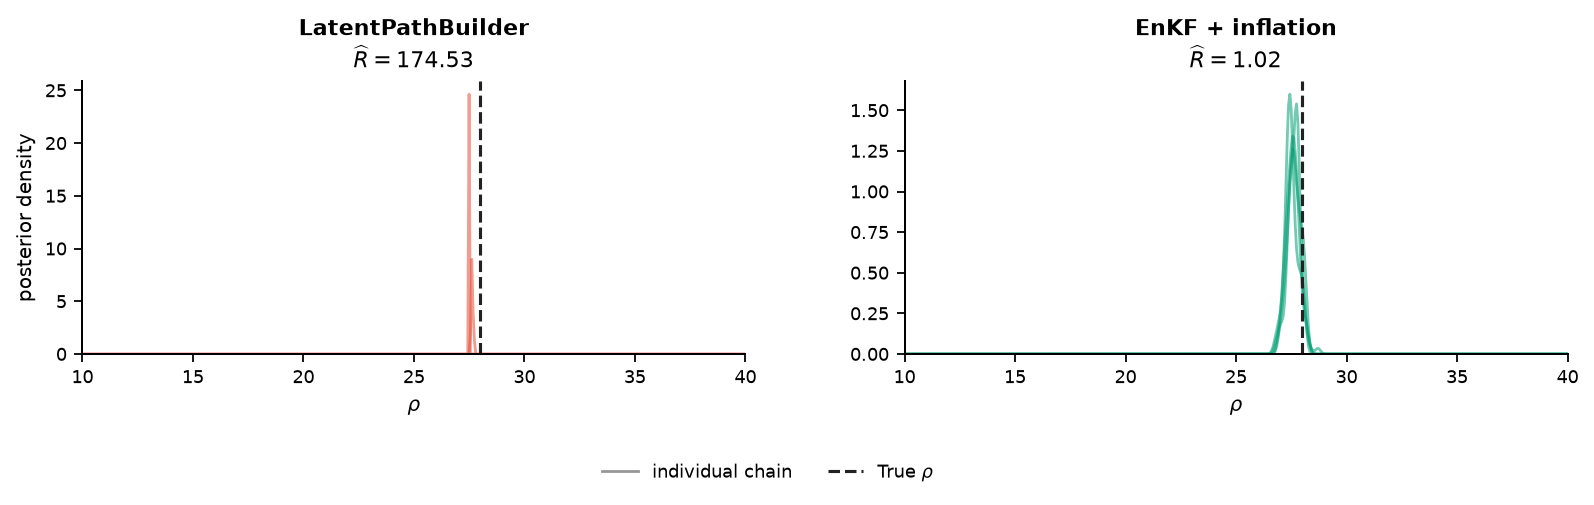

In [13]:
from scipy.stats import gaussian_kde

parameter_method_names = list(parameter_results)
parameter_table_lines = [
    "| Method | Median | 90% interval | R-hat | ESS | Divergences | Runtime [s] |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
for name in parameter_method_names:
    result = parameter_results[name]
    parameter_table_lines.append(
        f"| {name} | {result['median']:.3f} | "
        f"[{result['q05']:.3f}, {result['q95']:.3f}] | "
        f"{result['r_hat']:.3f} | {result['n_eff']:.1f} | "
        f"{result['divergences']} | {result['elapsed']:.2f} |"
    )
display(Markdown("\n".join(parameter_table_lines)))

rho_grid = np.linspace(10.0, 40.0, 500)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.1), sharex=True)
for ax, name in zip(axes, parameter_method_names, strict=True):
    result = parameter_results[name]
    color = METHOD_COLORS[name]
    for chain_samples in result["rho_by_chain"]:
        if np.ptp(chain_samples) > 1e-8:
            density = gaussian_kde(chain_samples)(rho_grid)
            ax.plot(
                rho_grid,
                density,
                color=color,
                linewidth=1.25,
                alpha=0.55,
            )
        else:
            ax.axvline(
                chain_samples[0],
                color=color,
                linewidth=1.25,
                alpha=0.55,
            )
    ax.axvline(
        TRUE_RHO,
        color=TRUTH_COLOR,
        linestyle="--",
        linewidth=1.4,
    )
    ax.set_title(
        f"{name}\n$\\widehat{{R}}={result['r_hat']:.2f}$",
        fontweight="bold",
    )
    ax.set_xlabel(r"$\rho$")
    ax.set_xlim(10.0, 40.0)
    ax.set_ylim(bottom=0.0)
    despine(ax)
axes[0].set_ylabel("posterior density")

legend_handles = [
    mpl.lines.Line2D(
        [], [], color=OBS_COLOR, linewidth=1.25, alpha=0.65, label="individual chain"
    ),
    mpl.lines.Line2D(
        [], [], color=TRUTH_COLOR, linestyle="--", linewidth=1.4, label=r"True $\rho$"
    ),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
)
fig.subplots_adjust(
    left=0.08, right=0.99, top=0.82, bottom=0.27, wspace=0.24
)
save_figure(fig, "rho_parameter_posteriors")
plt.show()

For the `LatentPathBuilder`, we see that chains generally collapsed/explored poorly (hence, a large $\hat{R}$). EnKF mixes much better, and has better MCMC diagnostics.

## Forecasting with posterior uncertainty in $\rho$

In some ways, the ultimate test of each method its ability to forecast. We thus forecast using the posterior estimate of the terminal $p(x_T \,|\, y_{0:T})$ and the posterior over $\rho$:

$$
p(x_t\mid y_{0:T})=\int p(x_t\mid x_T,\rho)\,p(x_T,\rho\mid y_{0:T})\,d x_T\,d\rho.
$$

In [14]:
FORECAST_FINAL_TIME = 10.0
N_LPB_FORECAST_DRAWS_PER_CHAIN = 40
N_ENKF_RHO_FORECAST_DRAWS = 40
N_ENKF_STATE_FORECAST_DRAWS = 10

forecast_mask = (dataset["times"] >= obs_times[-1] - 1e-12) & (
    dataset["times"] <= FORECAST_FINAL_TIME + 1e-12
)
forecast_times = dataset["times"][forecast_mask]
forecast_true_states = np.asarray(dataset["states"][forecast_mask])


def summarize_forecast(draws):
    return {
        "median": np.quantile(draws, 0.50, axis=0),
        "lo50": np.quantile(draws, 0.25, axis=0),
        "hi50": np.quantile(draws, 0.75, axis=0),
        "lo90": np.quantile(draws, 0.05, axis=0),
        "hi90": np.quantile(draws, 0.95, axis=0),
    }


# LatentPathBuilder: preserve paired (x_0, rho) draws within each chain.
lpb_result = parameter_results["LatentPathBuilder"]
lpb_rho_by_chain = lpb_result["rho_by_chain"]
lpb_state_params_by_chain = lpb_result["state_path_params_by_chain"]

if lpb_state_params_by_chain is None:
    raise RuntimeError("LatentPathBuilder state-path parameters were not retained.")

n_lpb_chains, n_lpb_draws = lpb_rho_by_chain.shape
n_lpb_forecast_draws = min(
    N_LPB_FORECAST_DRAWS_PER_CHAIN,
    n_lpb_draws,
)
lpb_draw_indices = np.linspace(
    0,
    n_lpb_draws - 1,
    n_lpb_forecast_draws,
    dtype=int,
)

lpb_forecast_rho = jnp.asarray(lpb_rho_by_chain[:, lpb_draw_indices].reshape(-1))
lpb_forecast_state_params = jnp.asarray(
    lpb_state_params_by_chain[:, lpb_draw_indices].reshape(
        (-1, *lpb_state_params_by_chain.shape[2:])
    )
)

lpb_predictive = Predictive(
    l63_partial_observation_model,
    posterior_samples={
        "rho": lpb_forecast_rho,
        "f_state_path_params": lpb_forecast_state_params,
    },
    exclude_deterministic=False,
)

with ODESimulator(simulator_config=ode_config):
    with dsx.LatentPathBuilder(ode_simulator_config=ode_config):
        lpb_forecast_samples = lpb_predictive(
            jr.PRNGKey(104),
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=forecast_times,
        )

lpb_forecast_states_raw = np.asarray(lpb_forecast_samples["f_predicted_states"])
lpb_forecast_draws_by_chain = lpb_forecast_states_raw.reshape(
    n_lpb_chains,
    n_lpb_forecast_draws,
    -1,
    forecast_times.shape[0],
    STATE_DIM,
).reshape(
    n_lpb_chains,
    -1,
    forecast_times.shape[0],
    STATE_DIM,
)
lpb_forecast_times = np.asarray(lpb_forecast_samples["f_predicted_times"]).reshape(
    -1, forecast_times.shape[0]
)[0]

lpb_chain_forecast_summaries = [
    summarize_forecast(chain_draws) for chain_draws in lpb_forecast_draws_by_chain
]


# EnKF: integrate over rho and the final filtering distribution.
enkf_result = parameter_results["EnKF + inflation"]
if not np.isfinite(enkf_result["r_hat"]) or enkf_result["r_hat"] > 1.05:
    raise RuntimeError(
        "The EnKF rho chains have not converged; do not form a pooled forecast."
    )

enkf_rho_pool = enkf_result["rho_by_chain"].reshape(-1)
n_enkf_rho_draws = min(
    N_ENKF_RHO_FORECAST_DRAWS,
    enkf_rho_pool.size,
)
enkf_rho_indices = np.random.default_rng(2026).choice(
    enkf_rho_pool.size,
    size=n_enkf_rho_draws,
    replace=False,
)
enkf_forecast_rho = jnp.asarray(enkf_rho_pool[enkf_rho_indices])

enkf_predictive = Predictive(
    l63_partial_observation_model,
    posterior_samples={"rho": enkf_forecast_rho},
    exclude_deterministic=False,
)

with dsx.DiscreteTimeSimulator(n_simulations=N_ENKF_STATE_FORECAST_DRAWS):
    with Filter(filter_config=parameter_enkf_config):
        with Discretizer(flow_config):
            enkf_forecast_samples = enkf_predictive(
                jr.PRNGKey(105),
                obs_times=obs_times,
                obs_values=obs_values,
                predict_times=forecast_times,
            )

enkf_forecast_states_raw = np.asarray(enkf_forecast_samples["f_predicted_states"])
enkf_forecast_draws = enkf_forecast_states_raw.reshape(
    -1,
    forecast_times.shape[0],
    STATE_DIM,
)
enkf_forecast_times = np.asarray(enkf_forecast_samples["f_predicted_times"]).reshape(
    -1, forecast_times.shape[0]
)[0]
enkf_forecast_summary = summarize_forecast(enkf_forecast_draws)

print(
    "LatentPathBuilder forecast draws per chain:",
    lpb_forecast_draws_by_chain.shape[1],
)
print(
    "EnKF forecast draws:",
    enkf_forecast_draws.shape[0],
)


LatentPathBuilder forecast draws per chain: 40
EnKF forecast draws: 400


| Forecast distribution | Overall RMSE | 90% coverage |
|---|---:|---:|
| LatentPathBuilder chain 1 | 12.039 | 0.117 |
| LatentPathBuilder chain 2 | 3.664 | 0.475 |
| LatentPathBuilder chain 3 | 9.961 | 0.250 |
| LatentPathBuilder chain 4 | 11.328 | 0.008 |
| EnKF + inflation | 4.125 | 0.875 |

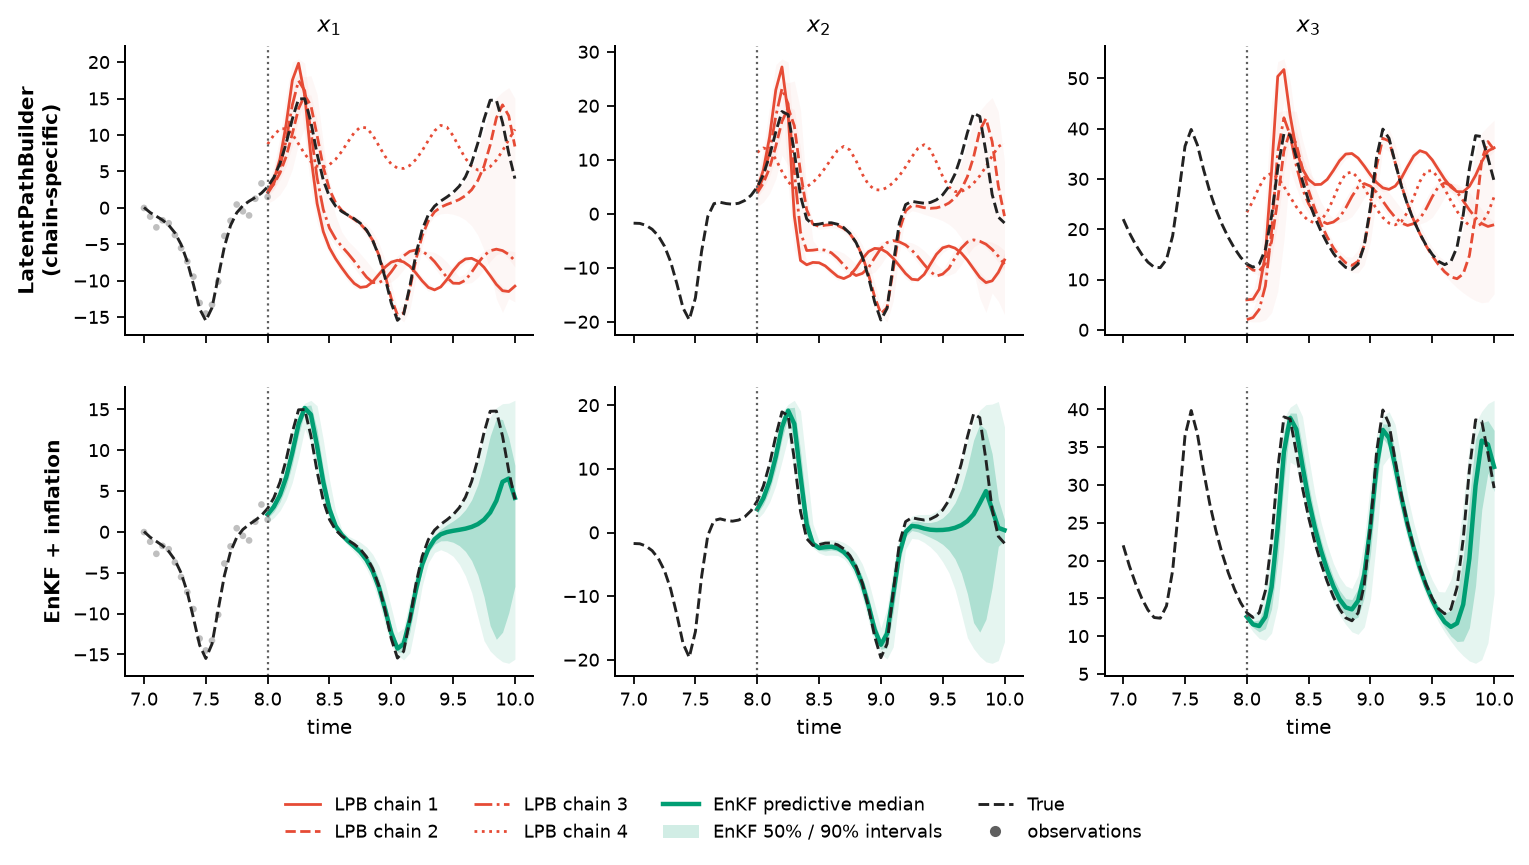

In [ ]:
forecast_eval_mask = enkf_forecast_times > float(obs_times[-1]) + 1e-12

def forecast_metrics(summary):
    error = (
        summary["median"][forecast_eval_mask] - forecast_true_states[forecast_eval_mask]
    )
    covered = (
        forecast_true_states[forecast_eval_mask] >= summary["lo90"][forecast_eval_mask]
    ) & (
        forecast_true_states[forecast_eval_mask] <= summary["hi90"][forecast_eval_mask]
    )
    return {
        "rmse": float(np.sqrt(np.mean(error**2))),
        "coverage": float(np.mean(covered)),
    }


forecast_metric_rows = []
for chain_index, summary in enumerate(lpb_chain_forecast_summaries):
    forecast_metric_rows.append(
        (
            f"LatentPathBuilder chain {chain_index + 1}",
            forecast_metrics(summary),
        )
    )
forecast_metric_rows.append(
    (
        "EnKF + inflation",
        forecast_metrics(enkf_forecast_summary),
    )
)

forecast_table_lines = [
    "| Forecast distribution | Overall RMSE | 90% coverage |",
    "|---|---:|---:|",
]
for name, metric in forecast_metric_rows:
    forecast_table_lines.append(
        f"| {name} | {metric['rmse']:.3f} | {metric['coverage']:.3f} |"
    )
display(Markdown("\n".join(forecast_table_lines)))

context_mask = (dataset["times"] >= obs_times[-1] - 1.0 - 1e-12) & (
    dataset["times"] <= FORECAST_FINAL_TIME + 1e-12
)
context_times = np.asarray(dataset["times"][context_mask])
context_true_states = np.asarray(dataset["states"][context_mask])
recent_obs_mask = obs_times >= obs_times[-1] - 1.0 - 1e-12

lpb_color = METHOD_COLORS["LatentPathBuilder"]
enkf_color = METHOD_COLORS["EnKF + inflation"]
lpb_chain_linestyles = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(
    2,
    STATE_DIM,
    figsize=(10.2, 5.4),
    sharex=True,
)

for state_index in range(STATE_DIM):
    lpb_ax = axes[0, state_index]
    enkf_ax = axes[1, state_index]

    for chain_index, summary in enumerate(lpb_chain_forecast_summaries):
        linestyle = lpb_chain_linestyles[chain_index % len(lpb_chain_linestyles)]
        lpb_ax.fill_between(
            lpb_forecast_times,
            summary["lo90"][:, state_index],
            summary["hi90"][:, state_index],
            color=lpb_color,
            alpha=0.045,
            linewidth=0,
        )
        lpb_ax.plot(
            lpb_forecast_times,
            summary["median"][:, state_index],
            color=lpb_color,
            linestyle=linestyle,
            linewidth=1.25,
        )

    enkf_ax.fill_between(
        enkf_forecast_times,
        enkf_forecast_summary["lo90"][:, state_index],
        enkf_forecast_summary["hi90"][:, state_index],
        color=enkf_color,
        alpha=0.10,
        linewidth=0,
    )
    enkf_ax.fill_between(
        enkf_forecast_times,
        enkf_forecast_summary["lo50"][:, state_index],
        enkf_forecast_summary["hi50"][:, state_index],
        color=enkf_color,
        alpha=0.24,
        linewidth=0,
    )
    enkf_ax.plot(
        enkf_forecast_times,
        enkf_forecast_summary["median"][:, state_index],
        color=enkf_color,
        linewidth=2.0,
    )

    for ax in (lpb_ax, enkf_ax):
        ax.plot(
            context_times,
            context_true_states[:, state_index],
            color=TRUTH_COLOR,
            linestyle="--",
            linewidth=1.3,
        )
        if state_index == 0:
            ax.scatter(
                np.asarray(obs_times[recent_obs_mask]),
                np.asarray(obs_values[recent_obs_mask, 0]),
                s=9,
                color=OBS_COLOR,
                alpha=0.40,
                edgecolors="none",
            )
        ax.axvline(
            float(obs_times[-1]),
            color=OBS_COLOR,
            linestyle=":",
            linewidth=1.0,
        )
        despine(ax)

    axes[0, state_index].set_title(
        rf"$x_{state_index + 1}$",
        fontweight="bold",
    )
    axes[1, state_index].set_xlabel("time")

axes[0, 0].set_ylabel(
    "LatentPathBuilder\n(chain-specific)",
    fontweight="bold",
)
axes[1, 0].set_ylabel(
    "EnKF + inflation",
    fontweight="bold",
)

forecast_legend_handles = [
    *[
        mpl.lines.Line2D(
            [],
            [],
            color=lpb_color,
            linestyle=lpb_chain_linestyles[index],
            linewidth=1.25,
            label=f"LPB chain {index + 1}",
        )
        for index in range(NUM_CHAINS)
    ],
    mpl.lines.Line2D(
        [],
        [],
        color=enkf_color,
        linewidth=2.0,
        label="EnKF predictive median",
    ),
    mpl.patches.Patch(
        facecolor=enkf_color,
        alpha=0.18,
        label="EnKF 50% / 90% intervals",
    ),
    mpl.lines.Line2D(
        [],
        [],
        color=TRUTH_COLOR,
        linestyle="--",
        linewidth=1.3,
        label="True",
    ),
    mpl.lines.Line2D(
        [],
        [],
        color=OBS_COLOR,
        marker="o",
        linestyle="none",
        markersize=4,
        label="observations",
    ),
]
fig.legend(
    handles=forecast_legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
)
fig.subplots_adjust(
    left=0.14,
    right=0.99,
    top=0.93,
    bottom=0.20,
    hspace=0.18,
    wspace=0.20,
)
save_figure(
    fig,
    "rho_posterior_predictive_forecast",
)
plt.show()


Like before, we see that the EnKF performs much better here: its estimates are more accurate over short timescales, and its calibration better over long timescales. There's also agreeance between chains for the EnKF, whereas the `LatentPathBuilder` gives bona fide differing solutions.

## Conclusions and Practical Guidelines

We showed in this notebook how we may learn from deterministic continuous-time dynamical systems (i.e., those whose states are driven by ODEs). The `LatentPathBuilder` gives a direct way to compute the likelihood, and therefore the posterior. However, it fails badly on the (chaotic) Lorenz-63 system. On the other hand, discretizing allowed effective state and parameter estimation (in the case of the EnKF). It is hard to make general practical recommendations, other than to visualize results carefully and strongly consider filtering methods in chaotic dynamical systems.